# 2.0 Data Exploration and Additional Data Rules
---
---
I need to give a summary of the investigation results see Investigation Results in obsidian
at the bottom i did a matrix of new fields i made make sure i summarise the results of that here

**Table Specifications**
- Table Location: data/interim
- Table name: stg_online_retail_orders
- Fields: 10
- Rows: 1.067,371
- File Size: 9.4 MB
- Approximate Memory Use: 184.8 MB

| **Field** | **Description** | **Data Type** | **Data Type Description** | **Example** |
| :--- | :--- | :--- | :--- | :--- |
| Invoice | This is the invoice number | String | Number or C+Number for cancellations | 516171 |
| StockCode | This is the product code| String | Number and additional admin/ops type letters | 22487 |
| Description | Full product description | String | String of concatenated key words | PLASTERS IN TIN SPACEBOY |
| Quantity | number of products measure | Integer 64 | There are negative numbers here for adjustments | 3 |
| InvoiceDate | Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| UnitPrice | Price of one line item | Float 64 | These are Pound Sterling and all positive | 0.39 |
| TotalPrice | Total price of lines items | Float 64 | This is Quantity x UnitPrice in Pound Sterling | 1.17 |
| CustomerHashID | Pseudonymised customer number | String | Simulated hash using HMAC-SHA256 | 09c72970956ea... |
| Country | Full country names | String | Country names including regions/unspecified | UNITED KINGDOM |
| Cancellation | Flag for line item changes | Boolean | This is a True/False flag | False |

---
##### Data Exploration Log:
| **Tag** | **Topic** | **Description** | **Contributor** | **Date** |
| :--- | :--- | :--- | :--- | :--- |

i need to add the steps above which to keep it simple are:
load data,
data exploration,
apply rules,
apply adjustments,
export

---
# Load Data
---
---
First we load the data ready for Exploration Phase:

In [1]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/interim/stg_online_retail_orders.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("⏳ Importing df_stg_online_retail_orders Parquet to dataframe df_stg_online_retail_orders ..")
    df_stg_online_retail_orders = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe df_stg_online_retail_orders complete.")

⏳ Importing df_stg_online_retail_orders Parquet to dataframe df_stg_online_retail_orders ..
✅ Data loaded to dataframe df_stg_online_retail_orders complete.


---
# Additional Data Rules
---
---

We investigate and apply additional data rules to assist downstream analysis. We don't touch the original fields to allow for before / after comparison and use of all fields.

**This splits into two sections.**
1. Data Cleanse Rules included as additional fields at the end of the data set (rules 1 - 6). 
2. Data Exploration phase at the bottom supporting the implementation of those rules.

**First lets make a new interim dataframe:**

In [2]:
df_cleansed_retail_orders =   df_stg_online_retail_orders
print("✅ Data copied to dataframe df_cleansed_retail_orders.")

✅ Data copied to dataframe df_cleansed_retail_orders.


---
## Cleanse rule 1
There are system timing issues affecting the invoice date for the same invoice number.

**We Create the cleanse rule to add InvoiceDateMin and set it to the minimum invoice date:**

In [3]:
df_cleansed_retail_orders['InvoiceDateMin'] = df_cleansed_retail_orders.groupby('Invoice')['InvoiceDate'].transform('min')

print("✅ Cleanse 1: All line items for a given invoice now share the same invoice date timestamp.")

✅ Cleanse 1: All line items for a given invoice now share the same invoice date timestamp.


---
## Cleanse rule 2
There are stock codes that are not for products. We flag these.

**We Create the cleanse rule to add StockCodeType with flag:**

In [4]:
import numpy as np

# 1. Define the conditions
conditions = [
    df_cleansed_retail_orders['StockCode'] == 'B',
    df_cleansed_retail_orders['StockCode'] == 'D',
    df_cleansed_retail_orders['StockCode'] == 'M',
    df_cleansed_retail_orders['StockCode'] == 'S',
    df_cleansed_retail_orders['StockCode'] == 'C2',
    df_cleansed_retail_orders['StockCode'] == 'DOT',
    df_cleansed_retail_orders['StockCode'] == 'CRUK',
    df_cleansed_retail_orders['StockCode'] == 'POST',
    df_cleansed_retail_orders['StockCode'] == 'AMAZONFEE',
    df_cleansed_retail_orders['StockCode'] == 'BANK CHARGES',
    # Using startswith to group similar wordings
    df_cleansed_retail_orders['StockCode'].str.startswith('ADJUST'),  # Catches ADJUST and ADJUST2
    df_cleansed_retail_orders['StockCode'].str.startswith('TEST'),    # Catches TEST001 and TEST002
    df_cleansed_retail_orders['StockCode'].str.startswith('GIFT')     # Catches all GIFT 0001 spellings
]

# 2. Define the results for StockCodeType, eg M -> 'MANUAL'
choices = [ 'ADJUST BAD DEBT', 'DISCOUNT', 'MANUAL', 'SAMPLES', 'CARRIAGE', 'DOTCOM POSTAGE', 'CANCER RESEARCH COMMISSION', 'POSTAGE', 'AMAZON FEE', 'BANK CHARGES', 'ADJUSTMENT', 'TEST PRODUCT', 'GIFT VOUCHER' ]

# 3. Apply to StockCodeType and default the rest of the Stock Codes to 'PRODUCT'
df_cleansed_retail_orders['StockCodeType'] = np.select( condlist=conditions, choicelist=choices, default='PRODUCT' )

print("✅ Cleanse 2: All line items now have their stock code type flagged.")

✅ Cleanse 2: All line items now have their stock code type flagged.


---
## Cleanse rule 3
There are description types that are not for products. We flag these.

**We Create the cleanse rule to add DescriptionType with flag:**

In [5]:
import numpy as np

# 1. Load the reference table
df_mapping = pd.read_csv('description_mapping.csv')

# 2. Create a dictionary from the CSV
mapping_dict = dict(zip(df_mapping['Description'], df_mapping['DescriptionType']))

# 3. Update field DescriptionType where it matches the reference table.
df_cleansed_retail_orders['DescriptionType'] = df_cleansed_retail_orders['Description'].map(mapping_dict)

# 4. Flag the records that did not get assigned a mapping and are not null
is_valid_product = df_cleansed_retail_orders['Description'].notna() & df_cleansed_retail_orders['DescriptionType'].isna()

# 5. Define these as 'PRODUCT' in the DescriptionType field
df_cleansed_retail_orders.loc[is_valid_product, 'DescriptionType'] = 'PRODUCT'


print("✅ Cleanse 3: All line items now have their description type flagged.")

✅ Cleanse 3: All line items now have their description type flagged.


---
## Cleanse rule 4
There are product itemisations that are not sales nor returns but relate to warehouse stock control. We flag these.

**We Create the cleanse rule to add WarehouseInventory with flag:**

In [6]:
import numpy as np
# 1. Create temporary field to check if the invoice is £0.00
df_cleansed_retail_orders['Max_Invoice_Price'] = df_cleansed_retail_orders.groupby('Invoice')['UnitPrice'].transform('max')

# 2. Define conditions that the invoice is £0.00 and Quantity is either positive (Add Stock) or negative (Remove Stock)
conditions = [
    (df_cleansed_retail_orders['Max_Invoice_Price'] == 0) & (df_cleansed_retail_orders['Quantity'] > 0),
    (df_cleansed_retail_orders['Max_Invoice_Price'] == 0) & (df_cleansed_retail_orders['Quantity'] < 0)
]

# 3. Define the choices
choices = [
    'ADD STOCK',
    'REMOVE STOCK'
]

# 4. Apply the flag. Other transaction types such as mixed invoices or regular sales default to NaN
df_cleansed_retail_orders['WarehouseInventory'] = np.select(
    condlist=conditions, 
    choicelist=choices, 
    default=None  
)

# 5. Drop temporary field
df_cleansed_retail_orders = df_cleansed_retail_orders.drop(columns=['Max_Invoice_Price'])

print("✅ Cleanse 4: All line items now have if they are 'warehouse inventory' flagged.")

✅ Cleanse 4: All line items now have if they are 'warehouse inventory' flagged.


---
## Cleanse rule 5
There are cancellations that are not for sales nor returns but are invoice line re-keys. We flag these.

**We Create the cleanse rule to add CancellationType with flag:**

In [7]:
import pandas as pd
import numpy as np

# 1. Create the object 'CancellationType' (set to NaN)
df_cleansed_retail_orders['CancellationType'] = np.nan
df_cleansed_retail_orders['CancellationType'] = df_cleansed_retail_orders['CancellationType'].astype('object')

# 2. Create temporary dataframe with the required fields
print("⏳ Setting up line-item arrays for matching ..")
temp_df = df_cleansed_retail_orders[[
    'Invoice', 'StockCode', 'Quantity', 'InvoiceDate', 
    'Cancellation', 'UnitPrice', 'CustomerHashID'
]].copy()

# Fill NaN in Customer so identical missing customers still match each other
temp_df['CustomerHashID'] = temp_df['CustomerHashID'].fillna('UNKNOWN')
temp_df['Abs_Quantity'] = temp_df['Quantity'].abs()
temp_df['Date'] = temp_df['InvoiceDate'].dt.date

# Create Signature per line: (StockCode, UnitPrice, Abs_Quantity)
temp_df['Line_Sig'] = tuple(zip(temp_df['StockCode'], temp_df['UnitPrice'], temp_df['Abs_Quantity']))

# Keep track of original dataframe indices to update stamps exactly where they belong
temp_df['Orig_Index'] = temp_df.index

# Separate into Cancels and Normals
is_cancel = temp_df['Cancellation'] == True
cancels_df = temp_df[is_cancel]
normals_df = temp_df[~is_cancel]

# 3. Group by Invoice to prepare line items for comparison
def build_invoice_dict(df):
    inv_dict = {}
    for inv, group in df.groupby('Invoice'):
        date_val = group['Date'].iloc[0]
        cust_val = group['CustomerHashID'].iloc[0]
        
        # Use zipping
        lines =[{'Index': idx, 'Sig': sig} for idx, sig in zip(group['Orig_Index'], group['Line_Sig'])]
        
        inv_dict[inv] = {
            'Date': date_val,
            'Customer': cust_val,
            'Lines': lines,
            'TotalLines': len(lines)
        }
    return inv_dict

print("⏳ Compiling Invoice Dictionaries ..")
cancels = build_invoice_dict(cancels_df)
normals = build_invoice_dict(normals_df)

# Pre-group normal invoices by (Date, Customer) for lookup
normals_by_date_cust = {}
for inv, data in normals.items():
    key = (data['Date'], data['Customer'])
    if key not in normals_by_date_cust:
        normals_by_date_cust[key] = []
    normals_by_date_cust[key].append(inv)

matched_normal_invoices = set()
stamps_to_apply = {} # Dictionary mapping Orig_Index -> String Stamp

print("⏳ Scanning for Re-Key overlaps at the line item level ..")

# 4. Do loop through cancellations and find matching re-keys
for c_inv, c_data in cancels.items():
    date_cust = (c_data['Date'], c_data['Customer'])
    candidates = normals_by_date_cust.get(date_cust,[])
    
    best_match = None
    best_Y = 0  # Number of overlapping lines
    best_matched_c_idx =[]
    best_matched_n_idx = []
    
    X = c_data['TotalLines']
    best_Z = 0
    
    for n_inv in candidates:
        if n_inv in matched_normal_invoices:
            continue
            
        n_data = normals[n_inv]
        Z = n_data['TotalLines']
        
        # Copy lists to separate from source data
        c_lines = c_data['Lines'].copy()
        n_lines = n_data['Lines'].copy()
        
        matched_c = []
        matched_n =[]
        
        # Find line signature intersects
        for c_line in c_lines:
            for i, n_line in enumerate(n_lines):
                if c_line['Sig'] == n_line['Sig']:
                    matched_c.append(c_line['Index'])
                    matched_n.append(n_line['Index'])
                    n_lines.pop(i) # Remove matched line to prevent duplication
                    break
        
        Y = len(matched_c)
        
        # If this candidate has the highest overlap so far, record it
        if Y > best_Y:
            best_Y = Y
            best_Z = Z
            best_match = n_inv
            best_matched_c_idx = matched_c
            best_matched_n_idx = matched_n
            
            # If perfect 1:1 match for all lines, stop checking candidates
            if Y == X and Y == Z:
                break
                
    # Apply logic based on the best match found
    if best_Y > 0:
        matched_normal_invoices.add(best_match)
        
        # Rule Check: Is it Full Invoice Re-Key or Line Item Re-key?
        if best_Y == X and best_Y == best_Z:
            stamp_val = 'FULL INVOICE RE-KEY'
        else:
            stamp_val = 'LINE ITEM RE-KEY'
            
        # Stamp the matching line items using original DataFrame indices
        for idx in best_matched_c_idx:
            stamps_to_apply[idx] = stamp_val
        for idx in best_matched_n_idx:
            stamps_to_apply[idx] = stamp_val

# 5. Apply the mapped stamps back to the main dataframe
print("\n📝 Applying Re-Key labels to DataFrame ..")
stamp_series = pd.Series(stamps_to_apply)
df_cleansed_retail_orders.loc[stamp_series.index, 'CancellationType'] = stamp_series

# 6. Apply cancellation label to the remaining Cancellations
print("📝 Applying 'Cancellation' labels to un-matched returns ..")
df_cleansed_retail_orders.loc[
    (df_cleansed_retail_orders['Cancellation'] == True) & 
    (df_cleansed_retail_orders['CancellationType'].isna()), 
    'CancellationType'
] = 'CANCELLATION'

print("\n✅ Cleanse 5: All cancellations that are re-keys are now flagged.")

⏳ Setting up line-item arrays for matching ..
⏳ Compiling Invoice Dictionaries ..
⏳ Scanning for Re-Key overlaps at the line item level ..

📝 Applying Re-Key labels to DataFrame ..
📝 Applying 'Cancellation' labels to un-matched returns ..

✅ Cleanse 5: All cancellations that are re-keys are now flagged.


---
## Cleanse rule 6
There are invoices that have CustomerHashID = Nan. These are guest checkout. We flag these.

**We Create the cleanse rule to add OrderCheckout with flag:**

In [8]:
# Create OrderCheckout field
df_cleansed_retail_orders['OrderCheckout'] = np.where(
    df_cleansed_retail_orders['CustomerHashID'].isna(),
    'GUEST CHECKOUT',
    'CUSTOMER ACCOUNT'
)

print("✅ Cleanse 6: OrderCheckout field now created with flags.")

✅ Cleanse 6: OrderCheckout field now created with flags.


---
---

### Pre-export Adjustments and Tests
**We do some data checks and adjustments on df_cleansed_retail_orders prior to exporting file to /data/interim:**

In [9]:
# Convert CancellationType from object to string, normalizing all null variants to NaN
df_cleansed_retail_orders['CancellationType'] = df_cleansed_retail_orders['CancellationType'].astype('str')

print("✅ CancellationType converted to string dtype.")

✅ CancellationType converted to string dtype.


**Overwrite DescriptionType with non product codes from StockCodeType:**

In [10]:
import numpy as np

# 1. Align DescriptionType to StockCodeType for admin codes mis-flagged as PRODUCT
admin_codes = [
    'ADJUST BAD DEBT', 'ADJUSTMENT', 'AMAZON FEE', 'BANK CHARGES',
    'CANCER RESEARCH COMMISSION', 'CARRIAGE', 'DISCOUNT', 'DOTCOM POSTAGE',
    'GIFT VOUCHER', 'MANUAL', 'POSTAGE', 'TEST PRODUCT'
]
mask_admin = (
    df_cleansed_retail_orders['StockCodeType'].isin(admin_codes) &
    (
        (df_cleansed_retail_orders['DescriptionType'] == 'PRODUCT') |
        df_cleansed_retail_orders['DescriptionType'].isna()
    )
)
df_cleansed_retail_orders.loc[mask_admin, 'DescriptionType'] = df_cleansed_retail_orders.loc[mask_admin, 'StockCodeType']

print("✅ DescriptionType aligned with StockCodeType for non product codes.")

✅ DescriptionType aligned with StockCodeType for non product codes.


**Handle Test Product so StockCodeType and DescriptionType say Test Product and OrderCheckout and CustomerHashID is NaN:**

In [11]:
mask_test = (
    (df_cleansed_retail_orders['StockCodeType'] == 'TEST PRODUCT') |
    (df_cleansed_retail_orders['DescriptionType'] == 'TEST PRODUCT')
)

df_cleansed_retail_orders.loc[mask_test, 'StockCodeType']      = 'TEST PRODUCT'
df_cleansed_retail_orders.loc[mask_test, 'DescriptionType']    = 'TEST PRODUCT'
df_cleansed_retail_orders.loc[mask_test, 'OrderCheckout']      = 'TEST ACCOUNT'
df_cleansed_retail_orders.loc[mask_test, 'CustomerHashID']     = np.nan
df_cleansed_retail_orders.loc[mask_test, 'WarehouseInventory'] = np.nan

print("✅ StockCodeType and DescriptionType aligned for test products.")

✅ StockCodeType and DescriptionType aligned for test products.


**Change OrderCheckout to Warehouse Adjustment where DescriptionType implies warehouse inventory change:**

In [12]:
warehouse_desc_types = ['ADJUSTMENT', 'ADMIN', 'DAMAGED', 'PRODUCT', 'STOCK CHECK']

mask_warehouse_adj = (
    (df_cleansed_retail_orders['StockCodeType'] == 'PRODUCT') &
    df_cleansed_retail_orders['WarehouseInventory'].notna() &
    (
        df_cleansed_retail_orders['DescriptionType'].isin(warehouse_desc_types) |
        df_cleansed_retail_orders['DescriptionType'].isna()
    )
)

df_cleansed_retail_orders.loc[mask_warehouse_adj, 'OrderCheckout'] = 'WAREHOUSE ADJUSTMENT'

print("✅ OrderCheckout tagged as WAREHOUSE ADJUSTMENT for stock control changes.")

✅ OrderCheckout tagged as WAREHOUSE ADJUSTMENT for stock control changes.


**Overwrite WarehouseInventory to NaN where the description type looks unrelated to warehouse inventory:**

In [13]:
non_warehouse_desc_types = ['AMAZON', 'CLERICAL ERROR', 'DONATION', 'DOTCOM', 'EBAY', 'POSTAGE',
                            'PRODUCT RETURN', 'SAMPLES', 'SHOW ROOM']

mask_non_warehouse = (
    (df_cleansed_retail_orders['StockCodeType'] == 'PRODUCT') &
    df_cleansed_retail_orders['WarehouseInventory'].notna() &
    df_cleansed_retail_orders['DescriptionType'].isin(non_warehouse_desc_types)
)

df_cleansed_retail_orders.loc[mask_non_warehouse, 'WarehouseInventory'] = np.nan

where_stock_code_not_product = ['CARRIAGE', 'DOTCOM POSTAGE', 'GIFT VOUCHER', 'MANUAL', 'POSTAGE']

mask_non_warehouse2 = (
    df_cleansed_retail_orders['StockCodeType'].isin(where_stock_code_not_product) &
    df_cleansed_retail_orders['WarehouseInventory'].notna() &
    df_cleansed_retail_orders['DescriptionType'].isin(where_stock_code_not_product)
)

df_cleansed_retail_orders.loc[mask_non_warehouse2, 'WarehouseInventory'] = np.nan

print("✅ WarehouseInventory cleared for admin type changes.")

✅ WarehouseInventory cleared for admin type changes.


---
**Get the specifications of the cleased data set:**

In [14]:
# Check column names, data types, and non-null counts
df_cleansed_retail_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Invoice             1067371 non-null  str           
 1   StockCode           1067371 non-null  str           
 2   Description         1062989 non-null  str           
 3   Quantity            1067371 non-null  int64         
 4   InvoiceDate         1067371 non-null  datetime64[us]
 5   UnitPrice           1067371 non-null  float64       
 6   TotalPrice          1067371 non-null  float64       
 7   CustomerHashID      824348 non-null   str           
 8   Country             1067371 non-null  str           
 9   Cancellation        1067371 non-null  bool          
 10  InvoiceDateMin      1067371 non-null  datetime64[us]
 11  StockCodeType       1067371 non-null  str           
 12  DescriptionType     1063024 non-null  str           
 13  WarehouseInventory  519

---
# Export data
---
---

**We push df_cleansed_retail_orders to folder data/interim, file cleansed_online_retail_orders.parquet:**

In [15]:
import os
# We use parquet format to preserve datatypes in the output file
# run pip install pyarrow in terminal if you don't have it

# Define the output path for the transformed data
output_parquet_path = '../data/interim/cleansed_online_retail_orders.parquet'
output_dir = os.path.dirname(output_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(output_dir):
    print(f"❌ ERROR: The directory '{output_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(output_parquet_path):
    print(f"⏳ Exporting online retail orders data to {output_parquet_path} ..")
    df_cleansed_retail_orders.to_parquet(output_parquet_path, index=False)
    print("✅ Export complete.")

# 3. If file already exists, skip the export and advise to review.
else:
    print(f"❌ File '{output_parquet_path}' already exists.")
    print("  .. Skipping export.")
    print("  Please review/delete existing file, prior to re-running this cell.")

⏳ Exporting online retail orders data to ../data/interim/cleansed_online_retail_orders.parquet ..
✅ Export complete.


---
# Table Specifications
---
---

#### **Table name:** cleansed_retail_orders
- Fields: 15
- Rows: 1.067,371
- File Size: 9.5MB
- Approximate Memory Use: 256 MB

| **Field** | **Description** | **Data Type** | **Data Type Description** | **Example** |
| :--- | :--- | :--- | :--- | :--- |
| Invoice | This is the invoice number | String | Number or C+Number for cancellations | 516171 |
| StockCode | This is the product code| String | Number and additional admin/ops type letters | 22487 |
| Description | Full product description | String | String of concatenated key words | PLASTERS IN TIN SPACEBOY |
| Quantity | number of products measure | Integer 32 | There are negative numbers here for adjustments | 3 |
| InvoiceDate | Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| UnitPrice | Price of one line item | Float 32 | These are Pound Sterling and all positive | 0.39 |
| TotalPrice | Total price of lines items | Float 32 | This is Quantity x UnitPrice in Pound Sterling | 1.17 |
| CustomerHashID | Pseudonymised customer number | String | Simulated hash using HMAC-SHA256 | 09c72970956ea... |
| Country | Full country names | String | Country names including regions/unspecified | UNITED KINGDOM |
| Cancellation | Flag for line item changes | Boolean | This is a True/False flag | False |
| InvoiceDateMin | Remove system timing issue from Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| StockCodeType | Name of what it is, if not a stock code | Category | This is a string | Postage |
| DescriptionType | Summary of what it is, if not a stock code description | Category | This is a string | Damages |
| WarehouseInventory | These are warehouse stock control | Category | This is a string | Add Stock |
| CancellationType | More detail into what the cancellation is | Category | This is a string | Full Invoice Re-Key |
| OrderCheckout | Who raised the order | Category | This is a string | Customer Account |

---
# Data Exploration
---
---

We look at what is inside the fields, their relationship to each other such as one-to-one mappings and determining any category 

**First lets make a new interim dataframe:**

In [16]:
result = (
    df_cleansed_retail_orders
    .groupby(
        ['StockCodeType', 'DescriptionType', 'WarehouseInventory',
         'CancellationType', 'OrderCheckout'],
        dropna=False,    # keep NaN as its own group (SQL-like behaviour)
        observed=True    # only return combinations that actually occur
    )
    .size()
    .reset_index(name='Total')
    .sort_values(
        ['StockCodeType', 'DescriptionType', 'WarehouseInventory',
         'CancellationType', 'OrderCheckout'],
        na_position='last'
    )
    .reset_index(drop=True)
)

result

,StockCodeType,DescriptionType,WarehouseInventory,CancellationType,OrderCheckout,Total
0,ADJUST BAD DEBT,ADJUST BAD DEBT,NaN,NaN,GUEST CHECKOUT,6
1,ADJUSTMENT,ADJUSTMENT,NaN,CANCELLATION,CUSTOMER ACCOUNT,29
2,ADJUSTMENT,ADJUSTMENT,NaN,CANCELLATION,GUEST CHECKOUT,2
3,ADJUSTMENT,ADJUSTMENT,NaN,NaN,CUSTOMER ACCOUNT,35
4,ADJUSTMENT,ADJUSTMENT,NaN,NaN,GUEST CHECKOUT,4
...,...,...,...,...,...,...
73,PRODUCT,NaN,REMOVE STOCK,NaN,WAREHOUSE ADJUSTMENT,2688
74,SAMPLES,SAMPLES,NaN,CANCELLATION,GUEST CHECKOUT,101
75,SAMPLES,SAMPLES,NaN,NaN,GUEST CHECKOUT,3
76,TEST PRODUCT,TEST PRODUCT,NaN,CANCELLATION,TEST ACCOUNT,4


In [16]:
checky = df_cleansed_retail_orders[
    df_cleansed_retail_orders['WarehouseInventory'].isna() &
    df_cleansed_retail_orders['OrderCheckout'].isna() &
    df_cleansed_retail_orders['CancellationType'].isna() &
    (df_cleansed_retail_orders['StockCodeType'] != 'PRODUCT')
]

display(checky)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,TotalPrice,CustomerHashID,Country,Cancellation,InvoiceDateMin,StockCodeType,DescriptionType,WarehouseInventory,CancellationType,OrderCheckout
27994,491725,TEST001,THIS IS A TEST PRODUCT,10,2009-12-14 08:34:00,4.5,45.0,NaN,UNITED KINGDOM,False,2009-12-14 08:34:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
28251,491742,TEST001,THIS IS A TEST PRODUCT,5,2009-12-14 11:00:00,4.5,22.5,NaN,UNITED KINGDOM,False,2009-12-14 11:00:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
28254,491744,TEST001,THIS IS A TEST PRODUCT,5,2009-12-14 11:02:00,4.5,22.5,NaN,UNITED KINGDOM,False,2009-12-14 11:02:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
39398,492718,TEST001,THIS IS A TEST PRODUCT,5,2009-12-18 10:47:00,4.5,22.5,NaN,UNITED KINGDOM,False,2009-12-18 10:47:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
39411,492722,TEST002,THIS IS A TEST PRODUCT,1,2009-12-18 10:55:00,1.0,1.0,NaN,UNITED KINGDOM,False,2009-12-18 10:55:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
44614,493294,TEST002,NaN,1,2009-12-22 15:15:00,0.0,0.0,NaN,UNITED KINGDOM,False,2009-12-22 15:15:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
45228,493410,TEST001,THIS IS A TEST PRODUCT,5,2010-01-04 09:24:00,4.5,22.5,NaN,UNITED KINGDOM,False,2010-01-04 09:24:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
45230,493412,TEST001,THIS IS A TEST PRODUCT,5,2010-01-04 09:53:00,4.5,22.5,NaN,UNITED KINGDOM,False,2010-01-04 09:53:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
56117,494450,TEST001,THIS IS A TEST PRODUCT,5,2010-01-14 13:50:00,4.5,22.5,NaN,UNITED KINGDOM,False,2010-01-14 13:50:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN
66084,495295,TEST001,THIS IS A TEST PRODUCT,5,2010-01-22 13:30:00,4.5,22.5,NaN,UNITED KINGDOM,False,2010-01-22 13:30:00,TEST PRODUCT,TEST PRODUCT,NaN,NaN,NaN


---
### Invoice Codes:
- 1. Are there duplicate invoice codes across the time series?
- 2. How do the 7 varchar long invoice codes work (most flagged as cancelled)?

#### 1. We check for duplicate invoice numbers across the date range:

In [3]:
# ==========================
# Let's check the actual invoice dates for these duplicates

# Get unique Invoice + InvoiceDate combinations
invoice_fields = df_cleansed_retail_orders[['Invoice', 'InvoiceDate']].drop_duplicates()

# 2. Count occurrences of each Invoice in this distinct list
invoice_counts = invoice_fields['Invoice'].value_counts()

# 3. Filter for Invoices that appear on 2 or more distinct InvoiceDates
duplicated_invoices_list = invoice_counts[invoice_counts >= 2].index.tolist()

# 4. Create a dataframe of just these duplicated invoices and sort ascending by date
duplicated_invoices_df = invoice_fields[invoice_fields['Invoice'].isin(duplicated_invoices_list)]
duplicated_invoices_df = duplicated_invoices_df.sort_values(by=['Invoice', 'InvoiceDate'], ascending=[True, True])

# Display the unique Invoice and Date combinations
print(f"Found {len(duplicated_invoices_list)} Invoices with multiple distinct InvoiceDates.")
print("\nDuplicated Invoices and their Dates (Ordered by Date Ascending):")
display(duplicated_invoices_df)


# ==========================
# Then lets view the time differences formatted as days, hours, minutes to spot anything obvious

# Group by invoice to find the first and last timestamp
time_diff_df = duplicated_invoices_df.groupby('Invoice')['InvoiceDate'].agg(['min', 'max']).reset_index()

# Calculate difference
time_diff_df['TimeDelta'] = time_diff_df['max'] - time_diff_df['min']

# Format as xd, xh, xm using timedelta components
time_diff_df['DateDiff'] = time_diff_df['TimeDelta'].apply(
    lambda td: f"{td.components.days}d, {td.components.hours}h, {td.components.minutes}m"
)

# Display just Invoice and the formatted DateDiff
print("\nTime Difference between First and Last log for Duplicated Invoices:")
display(time_diff_df[['Invoice', 'DateDiff']])


# ==========================
# Then lets just summarise the invoices by time difference in days, hours, minutes to quantify it

# Create a summary by DateDiff
# Group by both TimeDelta and text field DateDiff
summary_df = time_diff_df.groupby(['TimeDelta', 'DateDiff']).size().reset_index(name='total')

# Sort by TimeDelta
summary_df = summary_df.sort_values('TimeDelta', ascending=True)

# Return the summary
summary_df = summary_df[['DateDiff', 'total']]

display(summary_df)

Found 83 Invoices with multiple distinct InvoiceDates.

Duplicated Invoices and their Dates (Ordered by Date Ascending):


,Invoice,InvoiceDate
41630,492807,2009-12-20 12:28:00
41655,492807,2009-12-20 12:29:00
52310,494166,2010-01-12 09:47:00
52516,494166,2010-01-12 09:48:00
110024,499967,2010-03-03 14:06:00
...,...,...
988724,576057,2011-11-13 15:06:00
1024386,578548,2011-11-24 15:02:00
1024452,578548,2011-11-24 15:03:00
634376,C545569,2011-03-03 16:25:00



Time Difference between First and Last log for Duplicated Invoices:


,Invoice,DateDiff
0,492807,"0d, 0h, 1m"
1,494166,"0d, 0h, 1m"
2,499967,"0d, 0h, 1m"
3,500353,"0d, 0h, 1m"
4,500827,"0d, 0h, 1m"
...,...,...
78,571735,"0d, 0h, 1m"
79,574076,"0d, 0h, 1m"
80,576057,"0d, 0h, 1m"
81,578548,"0d, 0h, 1m"


,DateDiff,total
0,"0d, 0h, 1m",80
1,"0d, 0h, 2m",1
2,"0d, 0h, 4m",1
3,"0d, 0h, 9m",1


---
The 3 things we see from the above are:
- 166 rows of duplicates on 83 invoice numbers
- If we format to day, hour, minute it looks like there are many that are 1 minute
- If we summarise by DateDiff all 83 invoices with duplication are less than 10 minutes apart like some "system timing issue".

We can see that invoice numbers are not being recycled on later dates in this data extract.

Given that each invoice is unique to within the same several minutes, we clean this up to help with future analysis.

## Cleanse rule 1
**We set all invoices to the minimum invoice date:**

---
---
#### 2. How do the 7 varchar long invoice codes work (most flagged as cancelled)?

In step 1 of the Data Clean and Stage ETL we had  1,047,871 '6 digit long' invoices and 19,500 '7 varchar long' invoices but we only flagged 19,494 as cancelled.

**What are the missing 6?**

In [5]:

# Identify invoices starting with C
c_at_start = df_cleansed_retail_orders['Invoice'].str.startswith('C')

# Identify all invoices that are varchar 7
is_length_7 = df_cleansed_retail_orders['Invoice'].str.len() == 7

# Identify invoices that are varchar 7 and do not start with C
missing_invoices = is_length_7 & (~c_at_start)

# Filter the dataframe to only those rows
missing_rows = df_cleansed_retail_orders[missing_invoices]

# Display the results
print("\nThe missing 6 Invoices:")
print(missing_rows)

# Below we check the stock codes for bad debt and they match the other method above, IE that we don't find additional bad debt
# df_filtered = df_cleansed_retail_orders[df_cleansed_retail_orders['StockCode'] == 'B']
# display_df = df_filtered.head(10).copy()
# display(display_df)


The missing 6 Invoices:
        Invoice StockCode      Description  Quantity         InvoiceDate  \
179403  A506401         B  ADJUST BAD DEBT         1 2010-04-29 13:36:00   
276274  A516228         B  ADJUST BAD DEBT         1 2010-07-19 11:24:00   
403472  A528059         B  ADJUST BAD DEBT         1 2010-10-20 12:04:00   
825443  A563185         B  ADJUST BAD DEBT         1 2011-08-12 14:50:00   
825444  A563186         B  ADJUST BAD DEBT         1 2011-08-12 14:51:00   
825445  A563187         B  ADJUST BAD DEBT         1 2011-08-12 14:52:00   

        UnitPrice  TotalPrice CustomerHashID         Country  Cancellation  
179403  -53594.36   -53594.36            NaN  UNITED KINGDOM         False  
276274  -44031.79   -44031.79            NaN  UNITED KINGDOM         False  
403472  -38925.87   -38925.87            NaN  UNITED KINGDOM         False  
825443   11062.06    11062.06            NaN  UNITED KINGDOM         False  
825444  -11062.06   -11062.06            NaN  UNITED KING

Above we can see these are bad debt adjustments and they seem to account for the negative outliers we spotted in the ETL phase. in the year 2010 they look like quarterly adjustments.

---
#### Next we sample some of the Cancellation = True Invoices to see what is going on.

**Below invoice 'C489449' is a common example. Let's check the full customer records:**

In [6]:
# 1. Define the cancelled invoice we have for reference
selected_invoice = 'C489449'

# 2. Get the cancelled order to extract the exact CustomerHashID of the customer
cancelled_order = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'] == selected_invoice]

# 3. Isolate the CustomerHashID variable
selected_customer = cancelled_order['CustomerHashID'].iloc[0]

# 3. Filter the main dataset for this customer
customer_item_history = df_cleansed_retail_orders[
    (df_cleansed_retail_orders['CustomerHashID'] == selected_customer)
].copy()

# 4. Sort by InvoiceDate, Invoice and Description to make it easier to spot check
customer_item_history = customer_item_history.sort_values(['InvoiceDate', 'Invoice', 'Description'])

# 5. Display fields for investigation
fields_to_display = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'TotalPrice', 'CustomerHashID', 'Country', 'Cancellation']
to_investigate = customer_item_history[fields_to_display]

# Toggle the below on to see al records
# display(to_investigate)

display_df = to_investigate.head(5).copy()
display(display_df)

# 6. I exported this to .csv to open in Excel for easier manual checking
# cancel_spot_chk_csv_path = '../data/interim/cancellation_spot_check.csv'
# to_investigate.to_csv(cancel_spot_chk_csv_path, index=False)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,TotalPrice,CustomerHashID,Country,Cancellation
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,-15.0,0d0722c467b37fb70380822b7defe96c865d85de6996bb...,AUSTRALIA,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,-9.9,0d0722c467b37fb70380822b7defe96c865d85de6996bb...,AUSTRALIA,True
185,C489449,84970S,HANGING HEART ZINC T LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,-20.4,0d0722c467b37fb70380822b7defe96c865d85de6996bb...,AUSTRALIA,True
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,-35.4,0d0722c467b37fb70380822b7defe96c865d85de6996bb...,AUSTRALIA,True
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,-35.4,0d0722c467b37fb70380822b7defe96c865d85de6996bb...,AUSTRALIA,True


---
#### Below are the Excel Investigation results for this customer:

<img src="images/canc_spot_check0.png" alt="Rekey Logic" width="800"/>

**In the above example there are 10 invoice numbers.**
For the 8 invoices at the bottom:
- 2 customer orders with no associated cancellation
- 2 customer orders at the bottom with a clear pattern of {original order → cancel that order → rekey the original}

- 1 order with 2 invoices at the top might have the 'original order' missing due to the cutoff date of the dataset being 2009-12-01

There is a pattern of Same-Day Rekeys. These look like administrative changes.
 - For checking the health of the customer base with eg an RFM Analysis the financial value lines will net to the correct amount. However, we see for Frequency calculations 'Customer Order' is not the same as '(invoices) order' count, so a rule is needed to not artificially inflate that customer's engagement/loyalty score
 
**Next we look at a typical customer with cancellations (eg C504468) but no same-day rekey:**

<img src="images/canc_spot_check1.png" alt="Cancel Logic" width="600"/>

**There are 178 line items and we reduce them to the 42 related to the cancellations in order of InvoiceDate**
- There are full stock line cancellations eg row 13 'First Aid Tin' for row 10 
- There are partial line item adjustments row 16 'Memo Board Cottage Design' -1 for row 6 (quantity 4)
- We see a double entry cancellation rows 12 & 13 'Coffee Mugs Apple Design' for one stock order row 5?
- There is a different spelling for partial line item adjustment row 15 'Large Popcorn Holder' versus row 8 'Popcorn holder, Large'
- Possible duplication of entry cancellation rows 37 & 38 for one row 32
- There are two entry cancellation manual adjustments 33 & 34 with no description of what they are for

There are many different scenarios here and if we add that to the same-day rekey scenario including the start of dataset end of dataset cutoffs it becomes a lot of effort for little return to clean this up. 

This is more business process related that we feed this back to stake holders to revisit systems and process.

For now we have a better understanding of the data peculiarities (including miss-spellings)
- for RFM Analysis we can net financial lines and add rules to handle frequency 
- for Data Science and feature engineering we can use libraries such as `scikit-learn`, `NLTK`, and `spaCy` to handle typos and keywords

*(We might add an indicator for Bad Debt Adjustment and even same-day rekey but first let's check the rest of the information before looking to add any fields)*

---
---
## StockCode and Description
1. We look at StockCode spellings, Description Spellings and order of words.
2. We look at 'one-to-one' mapping between StockCode, Description and UnitPrice

**First we look at a sample of raw data from df_cleansed_retail_orders using Data Wrangler to give it the eyeball test:**

<img src="images/stock_eyeball_test0.png" alt="Stock Eyeball Test" width="800"/>

---
**Also we check one-to-one of StockCode → Description → UnitPrice:**

In [7]:
df_stock_selection = df_cleansed_retail_orders.groupby(['StockCode', 'Description', 'UnitPrice']).agg(
    Line_Items=('StockCode', 'size'),
    Total_Items=('Quantity', 'sum'),
    First_Invoice_Date=('InvoiceDate', 'min')
).reset_index().sort_values('StockCode')
display(df_stock_selection.head(10))

,StockCode,Description,UnitPrice,Line_Items,Total_Items,First_Invoice_Date
0,10002,INFLATABLE POLITICAL GLOBE,0.72,25,3176,2010-03-03 12:57:00
1,10002,INFLATABLE POLITICAL GLOBE,0.85,303,4244,2009-12-01 09:08:00
2,10002,INFLATABLE POLITICAL GLOBE,1.63,7,9,2011-01-19 15:08:00
3,10002,INFLATABLE POLITICAL GLOBE,1.66,60,181,2010-01-18 13:24:00
4,10002,INFLATABLE POLITICAL GLOBE,1.70,3,3,2009-12-10 09:49:00
5,10002R,ROBOT PENCIL SHARPNER,5.06,1,1,2010-01-25 17:36:00
6,10002R,ROBOT PENCIL SHARPNER,5.17,2,3,2009-12-02 14:43:00
7,10080,CHECK,0.00,1,22,2011-11-10 10:53:00
8,10080,GROOVY CACTUS INFLATABLE,0.39,21,301,2011-06-21 10:40:00
9,10080,GROOVY CACTUS INFLATABLE,0.85,7,14,2009-12-02 16:02:00


**Looking at both the above samples, first we look at the second table:**
- Starting with one-to-one
    - an admin adjustment "Check" is put against product code 10080 for 0 amount
    - there are different UnitPrice's against 10002 with no explanation why (eg inflation, discount, price change, clerical error, etc.)
- If we filter on UnitPrice = 0 and select unique rows we have:
    - StockCodes in the description
    - {Adjust.. ,Amazon.. ,  Amendment, Bad Quality, Bank Charges, Breakage.. , Broken.. , Cant Find.. , Check.. , Crack.. , Damage.. , DotCom.. , Gone, Lost, Missing, Mouldy, Postage, Smashed, Unsaleable, Wet, Wrong.. , etc } some are zero UnitPrice like Damage.. are zero
- If we filter on negative Quantity and select unique rows we have:
    - Discount (StockCode=D)
    - Manual (StockCode=M) some manual adjustment
    - Samples (StockCode=S)
    - Display and Display Stand
    - There are also NaN Description against a stock code
    - Ebay (StockCode=DCGS...)
    - Cruk Commission (StockCode=Cruk)
    - Postage (StockCode=Post)
    - Amazon Fee (StockCode=AmazonFee)
    - Adjust... (StockCode=Adjust)
    - Pads... (StockCode=Pads)
    - etc. there are not too many codes here to prevent us isolating them

**Looking at the first table:**
- StockCode appears to consist of three (and maybe more) types of stamp
    - StockCode digits
    - Letter at the end like some additional key for something extra
    - eg POST is in there for Postage which is a delivery charge, not a product code
- The Description field appears to be a concatenation of product related terms in any order
- There are some typos in there
- We can see {Charlie Lola, Charlie and Lola} which are different spellings of the same brand name
- We can see word groupings defining {Cultural Theme, Brand, Item (eg Tin), 'Item Type' (eg (for) Biscuits), Colour, Size (eg large), Quantity (eg Pack 20), etc.}

Generally we would not want to change the contents of StockCode and Description through some word cleansing or standardisation rules.

However, we would look to add flags or an extra identification field for:
- {Discount, Manual, Amazon Fee, Postage, Samples -> Free Sample, etc} 
- Categorisations such as DeliveryCharges for { Postage, etc.} , Incentives for {Discount, Free Sample, etc} and any other groupings
- Flag for NaN in the StockCode or Description, safer to exclude from analysis if there aren't many

**If we look at the raw order table df_cleansed_retail_orders:**
- Filtering on 'Amazon Fee' we have all CustomerHashID = NaN with Quantity -1 looks like a marketplace fee. If I set cancellation False there are several amazon fees that are positive ... these look like rekeys except for CustomerHashId NaN
- We also have 'Postage' with both NaN and populated CustomerHashID with Quantity -1 to -16 for cancellation True, which look like Postage refunds.
- So if we go back to those cancellations we have a few things: There are these rekeys for the rule CustomerHashID, and magnitude of TotalPrice match, sign of TotalPrice are opposite and it is same day. We also have line item rekeys like the Amazon Fee for CustomerHashID = NaN or bad debt line items that are also rekeys but CustomerHashID NaN. Then we have standard cancelation true with TotalPrice negative and traditional StockCode that would be Product Returns (or cancellations).
    - CustomerHashID NaN will be the 'Guest Checkout / Click to Ship' feature in the shopping cart. We will need to populate a customer field with CustomerHashID and GuestCheckout to apply the line item rule for Re-Keys across all records
- There are 4,382 rows with Description = NaN and CustomerHashID = NaN and zero UnitPrice but they have negative Quantites. These look like Stock Adjustments.

#### Next steps:
From all the above we will want additional fields. Since the order table is by line item, rather than having a true/false field for each Item we can have the category (field) with drop down of similar items.

**Actions, we can introduce the following cleanse rules:**
- 1 We can introduce field for StockCodeType to isolate the non-stock codes first like Bad Debt, Amazon Fee, Postage etc.
- 2 We can add True/False GuestCheckout field to allow us to exclude them from analysis or split them out in reporting.
- 3 We need something similar to 1 for Description like Damages, Breakage.. etc. → DescriptionType
- 4 We can introduce a Re-Key True/False Field so we can report it for process management but also remove them from analysis
- 5 We can add a 'Product Returns' flag where cancellation is true, it's a genuine Stock Code, it's not a Re-Key, it has negative quantity and its between 2 days to 3 weeks after for match on StockCode, CustomerHashID, UnitPrice (magnitude) and Quantity (magnitude) less then or equal to prior Line Item
- We may collapse 4 and 5 into one field

---
---
## Cleanse 2

We introduce the field **TransactionType** for each Stock Code and stamp it with what it is, eg. Line Item, Amazon Fee, etc.

**First lets isolate all the non-stock codes:**

In [8]:
StockCode_col = 'StockCode'  # set input to StockCode
s = df_cleansed_retail_orders['StockCode'].astype(str)
counts_by_length = s.str.len().value_counts().sort_index()
print("Counts by length:")
print(counts_by_length)
print("\nTotal rows:", len(s))


Counts by length:
StockCode
1       1713
2        283
3       1446
4       2158
5     932385
6     127591
7       1392
8        127
9         74
12       202
Name: count, dtype: int64

Total rows: 1067371


In [9]:
StockCode_col = 'StockCode'  # set input to StockCode
len_filter = 4  # We change the filter to spot check codes that are not product

# Filter for StockCode with specified length
filtered_df = df_cleansed_retail_orders[df_cleansed_retail_orders['StockCode'].astype(str).str.len() == len_filter]

# Get distinct StockCode and Description for the specified length
distinct_stock = filtered_df[['StockCode', 'Description']].drop_duplicates()

# Add count of rows for each StockCode
stock_counts = filtered_df.groupby('StockCode').size().reset_index(name='Total')
distinct_stock = distinct_stock.merge(stock_counts, on='StockCode', how='left')

# Group by StockCode and Description, aggregate, and sort
result = filtered_df.groupby(['StockCode', 'Description']).agg(
    Total=('StockCode', 'size'),          # Count(*)
    TotalPrice_Sum=('TotalPrice', 'sum')  # sum(TotalPrice)
).reset_index().sort_values(['StockCode', 'Description'])

print(f"Distinct StockCode and Description for length {len_filter}:")
display(result)
print(f"\nTotal distinct records: {len(distinct_stock)}")

Distinct StockCode and Description for length 4:


,StockCode,Description,Total,TotalPrice_Sum
0,CRUK,CRUK COMMISSION,16,-7933.43
1,PADS,PADS TO MATCH ALL CUSHIONS,19,-36.60
2,POST,POSTAGE,2115,112341.00



Total distinct records: 5


---
Below are the results we can use to create the cleanse rule.
##### StockCode Mapping Table:
| **StockCode** | **Description** | **StockCodeType** | **Rows** |
| :--- | :--- | :--- | :--- |
| B	| ADJUST BAD DEBT | ADJUST BAD DEBT | 6 |
| D	| DISCOUNT | DISCOUNT | 177 |
| M	| MANUAL | MANUAL | 1,426 |
| S	| SAMPLES | SAMPLES | 104 |
| C2 | CARRIAGE | CARRIAGE | 279 |
| DOT | DOTCOM POSTAGE | DOTCOM POSTAGE | 1,444 |
| CRUK | CRUK COMMISSION | CANCER RESEARCH COMMISSION | 16 |
| PADS | PADS TO MATCH ALL CUSHIONS | PRODUCT | 19 |
| POST | POSTAGE | POSTAGE | 2,115 |
| ADJUST | ADJUSTMENT BY JOHN ON 26 01 2010 16 | ADJUSTMENT | 3 |
| ADJUST2 | ADJUSTMENT BY PETER ON JUN 25 2010 | ADJUSTMENT | 3 |
| TEST001 | THIS IS A TEST PRODUCT | TEST PRODUCT | 15 |
| TEST002 | 	THIS IS A TEST PRODUCT | TEST PRODUCT | 1 |
| AMAZONFEE	| AMAZON FEE | AMAZON FEE | 43 |
| BANK CHARGES | BANK CHARGES | BANK CHARGES | 102 |
| GIFT 0001 10 | DOTCOMGIFTSHOP GIFT VOUCHER 10 00 | GIFT VOUCHER | 14 |
| GIFT 0001 20 | DOTCOMGIFTSHOP GIFT VOUCHER 20 00 | GIFT VOUCHER | 26 |
| GIFT 0001 20 | TO PUSH ORDER THROUGHA S STOCK WAS | GIFT VOUCHER | 1 |
| GIFT 0001 30 | DOTCOMGIFTSHOP GIFT VOUCHER 30 00 | GIFT VOUCHER | 24 |
| GIFT 0001 40 | DOTCOMGIFTSHOP GIFT VOUCHER 40 00 | GIFT VOUCHER | 5 |
| GIFT 0001 50 | DOTCOMGIFTSHOP GIFT VOUCHER 50 00 | GIFT VOUCHER | 6 |
| GIFT 0001 70 | DOTCOMGIFTSHOP GIFT VOUCHER 70 00 | GIFT VOUCHER | 1 |
| GIFT 0001 80 | DOTCOMGIFTSHOP GIFT VOUCHER 80 00 | GIFT VOUCHER | 2 |
| Stock Codes | eg HOME BUILDING BLOCK WORD | PRODUCT | 1,061,539 |

**We create the cleanse rule to add StockCodeType:**

---
---
## Cleanse 3

We introduce the field **DescriptionType** for each Description and stamp it with what it is, eg. Damaged, Showroom, Product etc.
This was checked in excel and then saved as .csv in notebooks/Description_Mapping.

Normally we would reach out to the business to ascertain the meaning of those descriptions that are not product descriptions. 

**We Create the cleanse rule to add DescriptionType:**

---
---
## Cleanse 4

We introduce the field **WarehouseInventory** for tracking product movements with zero unit price that have negative quantity as we would want to exclude Stock Control from our analysis. Given lots of them have Damaged or Lost written in the description these look like Inventory Control such as Inventory Shrinkage. They seem to follow a pattern of Description explicitly says Damaged, Broken, Lost etc or NaN and CustomerHashID = NaN (ie not associated to a customer account)

**We look at a sample of these:**

In [12]:
zero_transactions = df_cleansed_retail_orders[df_cleansed_retail_orders['UnitPrice'].abs() == 0]

display(zero_transactions[['Invoice', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerHashID', 'InvoiceDate', 'StockCodeType', 'DescriptionType']].sample(10))

,Invoice,StockCode,Description,Quantity,UnitPrice,CustomerHashID,InvoiceDate,StockCodeType,DescriptionType
264919,515001,21920,NaN,-2,0.0,NaN,2010-07-07 15:35:00,PRODUCT,NaN
83309,497118,35935,NaN,-10,0.0,NaN,2010-02-05 15:22:00,PRODUCT,NaN
641275,546148,85049D,,-100,0.0,NaN,2011-03-09 16:43:00,PRODUCT,PRODUCT
657164,547597,17011F,NaN,-18,0.0,NaN,2011-03-24 11:21:00,PRODUCT,NaN
104664,499416,21298,NaN,-15,0.0,NaN,2010-02-26 16:15:00,PRODUCT,NaN
646066,546666,79321,NaN,72,0.0,NaN,2011-03-15 15:14:00,PRODUCT,NaN
413860,528941,35833G,NaN,28,0.0,NaN,2010-10-25 15:30:00,PRODUCT,NaN
167661,505220,47504G,NaN,25,0.0,NaN,2010-04-21 10:27:00,PRODUCT,NaN
15883,490713,84347,NaN,-20,0.0,NaN,2009-12-07 15:26:00,PRODUCT,NaN
118231,500684,84925D,NaN,192,0.0,NaN,2010-03-09 12:33:00,PRODUCT,NaN


---
Looking at postive Quantity against zero UnitPrice below we have an example order where the Order Purchase fee is entered as a Manual Charge item line. This is not Inventory Control. This also looks B2C: 

<img src="images/Manual_Order.png" alt="Cancel Logic" width="600"/>

**Let's quantify this against invoices where all line items have UnitPrice = 0:**

In [13]:
# 1. Get a list of unique Invoices that have at least one item with UnitPrice = 0 and Quantity > 0
zero_price_items = (df_cleansed_retail_orders['UnitPrice'] == 0) & (df_cleansed_retail_orders['Quantity'] > 0)
invoices_with_zero_items = df_cleansed_retail_orders[zero_price_items]['Invoice'].unique()

# 2. Filter the main dataset to get all line items for these invoices
df_target_invoices = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'].isin(invoices_with_zero_items)]

# 3. Group by Invoice and find the Maximum UnitPrice for each invoice
# If Max UnitPrice > 0, there are charges associated to the invoice (like Postage, Manual or other stock codes)
# If Max UnitPrice == 0, the entire order was £0.00
invoice_summary = df_target_invoices.groupby('Invoice')['UnitPrice'].max().reset_index()

# 4. Separate and count the two scenarios
mixed_invoices = invoice_summary[invoice_summary['UnitPrice'] > 0]
zero_invoices = invoice_summary[invoice_summary['UnitPrice'] == 0]

# --- Print the Results ---
print(f"Total Invoices containing at least one Zero price item (Qty>0): {len(invoices_with_zero_items)}")
print("-" * 60)
print(f"1. Mixed Invoices (At least one Zero price line item):  {len(mixed_invoices)}")
print(f"2. ALL line items are £0.00:                            {len(zero_invoices)}")

Total Invoices containing at least one Zero price item (Qty>0): 1986
------------------------------------------------------------
1. Mixed Invoices (At least one Zero price line item):  125
2. ALL line items are £0.00:                            1861


Spot checking some of row "2. All Line Items are £0.00" from the data frame zero_invoices, they seem to be only one row per invoice that is 1-2-1 on Invoice to StockCode with NaN Description and NaN CustomerHashID and large Quantity. IE these look like Inventory Control. **Let's check this:**

Total 'Zero UnitPrice' Line Items: 1976
Items missing Customer ID: 1967 (99.5%)
Invoices with only one line item: 1798 out of 1861 (96.6%)
------------------------------------------------------------


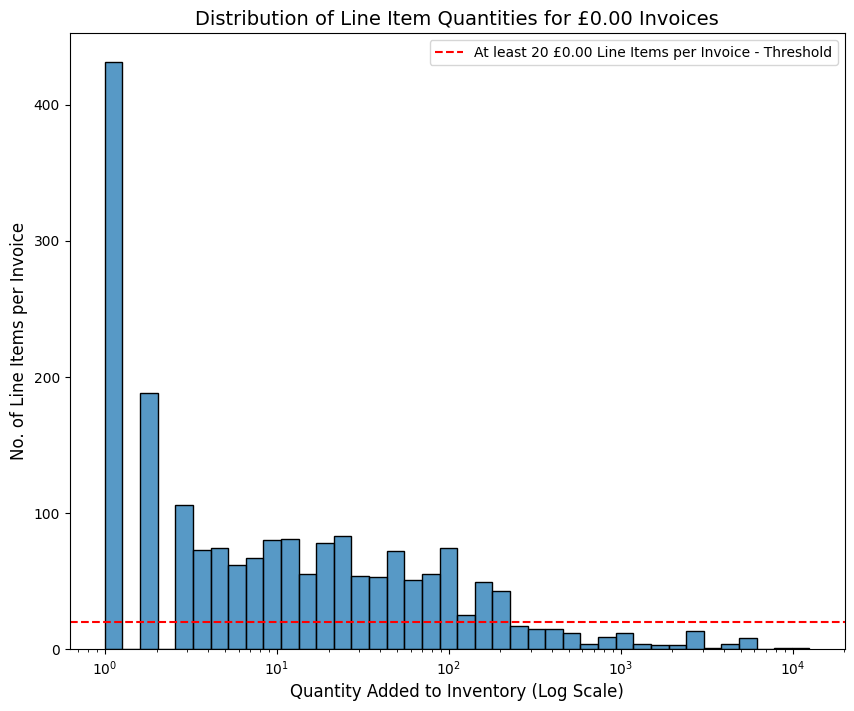

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the line items for the zero charge invoices
zero_invoice_list = zero_invoices['Invoice'].tolist()
df_zero_items = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'].isin(zero_invoice_list)]

# --- Check if these are Warehouse ---

# Check how many of these lack a CustomerHashID
missing_customer_count = df_zero_items['CustomerHashID'].isna().sum()
df_zero_items = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'].isin(zero_invoice_list)]
total_zeroed_items = len(df_zero_items)
print(f"Total 'Zero UnitPrice' Line Items: {total_zeroed_items}")
print(f"Items missing Customer ID: {missing_customer_count} ({(missing_customer_count/total_zeroed_items)*100:.1f}%)")

# Check if Invoice to StockCode is "One-to-One"
items_per_invoice = df_zero_items.groupby('Invoice').size()
single_item_invoices = (items_per_invoice == 1).sum()
total_zeroed_invs = len(items_per_invoice)
print(f"Invoices with only one line item: {single_item_invoices} out of {total_zeroed_invs} ({(single_item_invoices/total_zeroed_invs)*100:.1f}%)")
print("-" * 60)

# --- Graph: Quantity Distribution ---

plt.figure(figsize=(10, 8))
# Use bar chart with log scale to handle large numbers
ax = sns.histplot(data=df_zero_items, x='Quantity', bins=40, log_scale=(True, False))
plt.title('Distribution of Line Item Quantities for £0.00 Invoices', fontsize=14)
plt.xlabel('Quantity Added to Inventory (Log Scale)', fontsize=12)
plt.ylabel('No. of Line Items per Invoice', fontsize=12)

# Add a horizontal line at 20 to visually separate larger quantities that could indicate warehouse adjustments
plt.axhline(20, color='red', linestyle='--', label='At least 20 £0.00 Line Items per Invoice - Threshold')
plt.legend()
plt.show()

**The above graph shows a distibution of Inventory Line items where the total invoice price is £0.00:**
- In total we have 1,861 line items and they are counted in 40 buckets on the bottom axis.
- Since quantities added per line item range from 1 to several thousand we use a log scale on the horizontal axis.
- We add number of line items on the vertical axis and a red line at 20 line items per invoice to give an idea of "Bulk Adjustments"
- The far left bar at 400 is cut off, it should be 1,798. We cut it off to see the rest of the distribution.

Per the summary at the top, nearly all of these line items (99.5%) have no CustomerHashID and so are not associated to a customer and 96% of them are one-to-one on Invoice to Line Item (the 1,798). IE that it looks like someone has gone into the inventory to add Quantity +X against one product stock code that is unrelated to a customer transaction and added just one zero UnitPrice Invoice Line Item to account for it.

If the middle of the graph the rest of the Line Items appear to be "Bulk Adjustments" of 20 or more Line Items at £0.00 price for Quantities of stock ranging from 30 to several hundred per line item.

**In conclusion we have two (main) scenarios:**
1. mixed invoices where some line items are £0.00 but these are genuine customer orders
2. zero invoices where these clearly look like Warehouse Inventory Control (and which we want to flag)

In [15]:
# 1. Get a list of unique Invoices that have at least one item with UnitPrice = 0 and Quantity < 0
zero_price_items_minus = (df_cleansed_retail_orders['UnitPrice'] == 0) & (df_cleansed_retail_orders['Quantity'] < 0)
invoices_with_zero_items_minus = df_cleansed_retail_orders[zero_price_items_minus]['Invoice'].unique()

# 2. Filter the main dataset to get all line items for these invoices
df_target_invoices_minus = df_cleansed_retail_orders[df_cleansed_retail_orders['Invoice'].isin(invoices_with_zero_items_minus)]

# 3. Group by Invoice and find the Maximum UnitPrice for each invoice
# If Max UnitPrice > 0, there are charges associated to the invoice
# If Max UnitPrice == 0, the entire order was £0.00
invoice_summary_minus = df_target_invoices_minus.groupby('Invoice')['UnitPrice'].max().reset_index()

# 4. Separate and count the two scenarios
mixed_invoices_minus = invoice_summary_minus[invoice_summary_minus['UnitPrice'] > 0]
zero_invoices_minus = invoice_summary_minus[invoice_summary_minus['UnitPrice'] == 0]

# --- Print the Results ---
print(f"Let's do the same sense check on for Quantity less than 0): {len(invoices_with_zero_items_minus)}")
print("-" * 60)
print(f"1. Mixed Invoices (At least one Zero price line item):  {len(mixed_invoices_minus)}")
print(f"2. ALL line items are £0.00:                            {len(zero_invoices_minus)}")

Let's do the same sense check on for Quantity less than 0): 3393
------------------------------------------------------------
1. Mixed Invoices (At least one Zero price line item):  0
2. ALL line items are £0.00:                            3393


In [ ]:
# Check column names, data types, and non-null counts
df_cleansed_retail_orders.info()

---
We do the final check above for any mixed invoices with negative quantity. There aren't any they are all zero invoice line items.

We now use the above logic to create a cleanse rule to flag Warehouse Inventory Control, Add Stock / Remove Stock

**We Create the cleanse rule to add WarehouseInventory flag:**

In [19]:
testing =   df_cleansed_retail_orders
print("✅ Data copied for cancellation testing.")

✅ Data copied for cancellation testing.


---
---
## Cleanse 5 Add CancellationType Field

We use the following logic to identify cancellations that are Full Invoice ReKeys: We isolate all Cancellation invoices and check them against all other invoices that match on {CustomerHashID, StockCode, UnitPrice, |Quantity| (modulus), Day(InvoiceDate)}, where the other invoice is at the same or later time in the day (as we want to leave the original order untouched). We update CancelationType field as 'Re-Key'

We then use this logic to identify Product Returns: Where Cancellation is True and CancelationType is not 'Re-Key' we flag it as 'Product Return'

**Create CancellationType Field:**

---
---
## Cleanse 6 Add OrderCheckout Field

We previously identified 23% of CustomerHashID's are NaN. Since this is an Online Retail Store these are most likely customers using Guest Checkout. We add the field OrderCheckout to allow us to filter downstream


**Create OrderCheckout Field:**

In [ ]:
df_cleansed_retail_orders['CancellationType'].value_counts()

In [ ]:
# Comprehensive CancellationType analysis
print("=== CancellationType Column Analysis ===\n")

# 1. Data type and null count
print(f"Data Type: {df_cleansed_retail_orders['CancellationType'].dtype}")
print(f"Total rows: {len(df_cleansed_retail_orders)}")
print(f"Null/NaN count: {df_cleansed_retail_orders['CancellationType'].isna().sum()}\n")

# 2. Unique values
print(f"Unique values: {df_cleansed_retail_orders['CancellationType'].unique()}\n")

# 3. Value counts including NaN
print("Value Counts (including NaN):")
print(df_cleansed_retail_orders['CancellationType'].value_counts(dropna=False))
print(f"\nTotal: {df_cleansed_retail_orders['CancellationType'].value_counts(dropna=False).sum()}")